# A hot cup of chocolate milk

A tribute to Wim T. Schippers (1942-2026)

> Gé: (maakt zich los) ‘Wacht nou! We doen alles weer net als toen. Dus éérst:’
> 
> Jan: (glundert) ‘Een warme kop chocolademelk?’
> 
> Gé: (zet hem terecht) ‘Een kop warme chocolademelk. Niet een warme kop chocolademelk. Zeg dat toch niet altijd verkeerd.’
> 
> Jan: ‘Maar van die warme chocolademelk wordt die kóp toch óók warm?’

See: https://www.dbnl.org/tekst/_taa014200001_01/_taa014200001_01_0075.php

The cup is very abstract: it is modeled as an infinite cylinder, and we only consider its side wall. The chocolate milk is modeled as a heat reservoir of constant temperature.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyfvtool as pf

In [2]:
T_room = 293.15
T_cup_init = T_room
T_chocomilk = 355.0

c_p_cup = 0.105e3 # J kg-1 K-1 porcelain specific heat capacity
rho_cup = 2400.0 # kg m3 porcelain density
k_cup = 1.5 # W m-1 K-1 porcelain thermal conductivity
alpha_cup = k_cup / (rho_cup*c_p_cup)

h_chocomilk_cup = 500.0 # W m-2 K-1 (if you stir, this can be much higher)
h_cup_room = 20.0 # W m-2 K-1

R_exterior = 0.040 # m 
R_interior = 0.036 # m

Nr = 60

In [3]:
r = np.linspace(R_interior, R_exterior, Nr)

In [4]:
mesh = pf.CylindricalGrid1D(r)

In [5]:
T = pf.CellVariable(mesh, T_cup_init)

In [6]:
T.BCs.left.newtonCooling(k_cup, h_chocomilk_cup, T_chocomilk, reverse_direction=True)
T.BCs.right.newtonCooling(k_cup, h_cup_room, T_room)

In [7]:
dt = 0.025
Nt = 400
plotix = np.array(np.logspace(0, np.log10(Nt), 30).round(), dtype=int) - 1

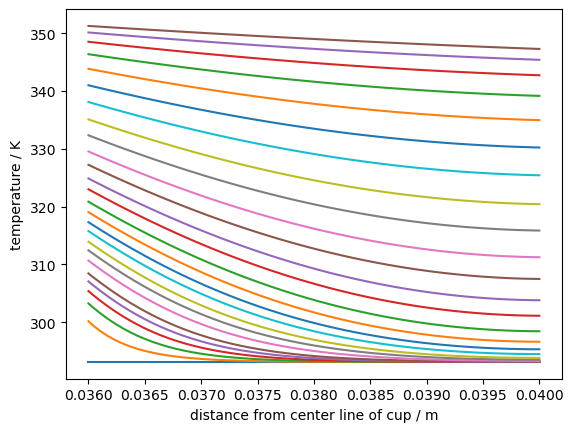

In [8]:
for it in range(Nt):
    if it in plotix:
        plt.plot(*T.plotprofile())
    pf.solvePDE(T, [ pf.transientTerm(T, dt),
                    -pf.diffusionTerm(pf.FaceVariable(mesh, alpha_cup))])
plt.xlabel('distance from center line of cup / m')
plt.ylabel('temperature / K');